In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = pd.read_csv("Zudio_sales_data.csv")

In [3]:
#dataset.drop(columns= ['Store','Country','State','Store Open Date','Order ID','Order Date','Selling Area Size (sq ft)','Store Manager','Manager ID','Contact Information'],inplace=True)

In [4]:
#dataset.drop(columns=['Store Address'],inplace=True)

In [5]:
(dataset.isnull().sum() / dataset.shape[0]) * 100

Store                         0.000000
Country                       0.000000
State                         0.000000
City                          0.000000
Category                      0.000000
Clothing Type                 0.000000
Store Number                  0.000000
Postal Code                   0.000000
Store Type                    0.000000
Store Open Date               0.000000
Selling Area Size (sq ft)     0.000000
Store Manager                 0.000000
Manager ID                    0.000000
Store Address                 0.000000
Contact Information           0.000000
Operating Hours               0.000000
Staff Count                   0.000000
Parking Availability          0.000000
Security Features            25.800734
Order ID                      0.000000
Order Date                    0.000000
Month                         0.000000
Customer ID                   0.000000
Customer Name                 0.000000
Product ID                    0.000000
Price                    

In [6]:
#dataset.drop(columns=['Security Features'],inplace=True)

In [7]:
dataset["Sales"] = dataset['Price'] * dataset['Quantity']

In [8]:
def open_hours(time):
    return 12 - int(time.split("-")[0].strip(" ")[:2]) + int(time.split("-")[1].strip(" ")[:2].strip(" "))

In [9]:
dataset['Open Hours'] = dataset['Operating Hours'].apply(open_hours)

In [10]:
dataset

,Store,Country,State,City,Category,Clothing Type,Store Number,Postal Code,Store Type,Store Open Date,...,Order Date,Month,Customer ID,Customer Name,Product ID,Price,Quantity,Sales Profit,Sales,Open Hours
0,Zudio,India,Karnataka,Jalna,Women,Dresses,30,411084,Owned,2022-06-04,...,2024-11-06,November,233084,Michele Ochoa,354,1958,5,3916.0,9790,9
1,Zudio,India,Gujarat,Patna,Kids,Skirts,48,404562,Owned,2020-12-19,...,2024-06-17,June,926472,Daniel Jimenez,741,2078,1,831.2,2078,11
2,Zudio,India,Uttar Pradesh,Kolkata,Men,Hoodies,97,437773,Rented,2023-09-04,...,2024-08-17,August,853255,Steven Davis,607,1445,2,1156.0,2890,11
3,Zudio,India,West Bengal,Kolkata,Women,Dresses,93,431725,Owned,2024-04-11,...,2024-03-27,March,106146,Derek Orozco,991,2469,6,5925.6,14814,9
4,Zudio,India,West Bengal,Guwahati,Men,Dresses,51,415370,Owned,2022-05-29,...,2024-04-08,April,264070,Victor Arnold,479,1105,6,2652.0,6630,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7894,Zudio,India,Uttar Pradesh,Chandigarh,Kids,Jeans,32,431437,Owned,2024-04-24,...,2024-09-27,September,591993,Tracey Andrews,262,2838,1,1135.2,2838,9
7895,Zudio,India,Uttar Pradesh,Aurangabad,Kids,Jackets,52,424643,Owned,2024-02-03,...,2024-03-16,March,822244,Linda Wallace,537,1814,2,1451.2,3628,9
7896,Zudio,India,Tamil Nadu,Pune,Kids,T-shirts,81,412057,Owned,2021-04-11,...,2024-12-02,December,268376,Brandon Baker,457,1961,1,784.4,1961,11
7897,Zudio,India,Delhi,Madurai,Men,Shoes,58,405203,Rented,2022-06-17,...,2024-07-29,July,766283,John Lewis,608,1017,8,3254.4,8136,9


1. Store Performance Optimization
Problem:
Some stores are underperforming compared to others, but the company doesn’t know
why.
What to analyze:
• Revenue by store (price × quantity)
• Impact of store type (Owned vs Rented)
• Compare across city, state
Business outcome:
Identify which stores to expand, improve, or shut down.

In [11]:
temp_data = pd.DataFrame(dataset.groupby(by='Store Number')['Sales'].sum()).sort_values(by="Sales")[ :5]

In [12]:
temp_data

,Sales
Store Number,
29,457248
35,464675
67,467456
21,472964
66,473607


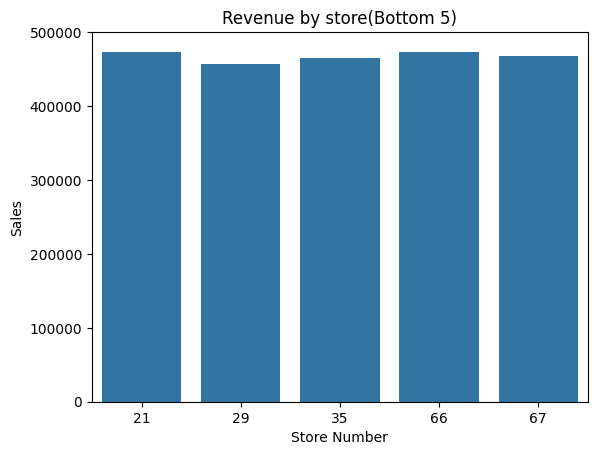

In [13]:
sns.barplot(x = "Store Number" , y = "Sales" , data=temp_data)
plt.yticks([i for i in range(0,600000,100000)])
plt.title("Revenue by store(Bottom 5)")
plt.show()

In [14]:
temp_data = pd.DataFrame(dataset.groupby(by='Store Number')['Sales'].sum()).sort_values(by="Sales",ascending=False)[:5]

In [15]:
temp_data

,Sales
Store Number,
68,865489
13,852783
43,839187
82,803065
78,790938


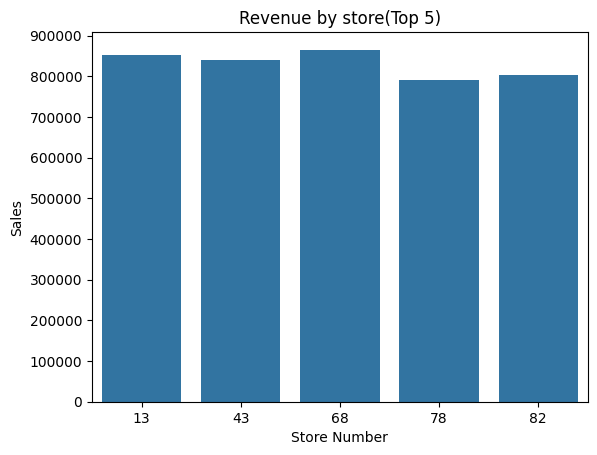

In [16]:
sns.barplot(x = "Store Number" , y = "Sales" , data=temp_data)
plt.yticks([i for i in range(0,1000000,100000)])
plt.title("Revenue by store(Top 5)")
plt.show()

In [17]:
temp_data = pd.DataFrame(dataset.groupby(by="Store Type")['Sales'].sum())

In [18]:
temp_data.reset_index(inplace=True)

In [19]:
temp_data

,Store Type,Sales
0,Owned,31185545
1,Rented,31427288


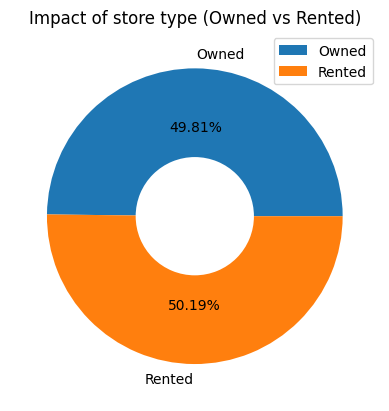

In [20]:
plt.pie(temp_data["Sales"], labels=temp_data["Store Type"],autopct="%0.2f%%",pctdistance=0.6)
plt.legend()
plt.title("Impact of store type (Owned vs Rented)")
plt.pie([1],radius=0.4, colors="white")
plt.show()

In [21]:
temp_data = pd.DataFrame(dataset.groupby(by='City')["Sales"].sum()).sort_values(by="Sales")[ :5]

In [22]:
temp_data

,Sales
City,
Mumbai,1163265
Thane,1241923
Solapur,1308477
Guwahati,1313652
Aurangabad,1316227


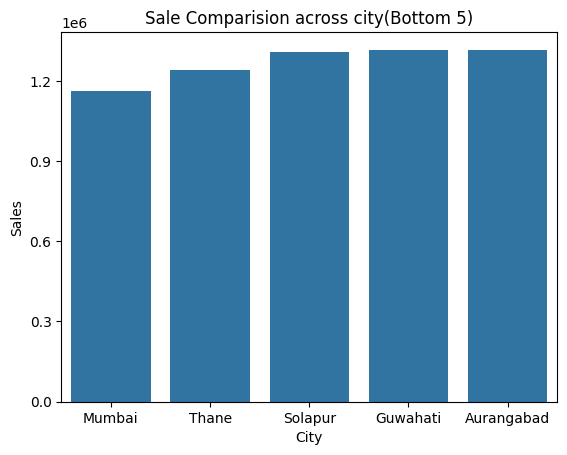

In [23]:
sns.barplot(x = "City" , y = "Sales" , data=temp_data)
plt.yticks([i for i in range(0,1500000,300000)])
plt.title("Sale Comparision across city(Bottom 5)")
plt.show()

In [24]:
temp_data = pd.DataFrame(dataset.groupby(by='City')["Sales"].sum()).sort_values(by="Sales",ascending=False)[ :5]
temp_data

,Sales
City,
Jalna,1719676
Mysuru,1703579
Jammu,1664596
Kolkata,1645961
Bhopal,1645597


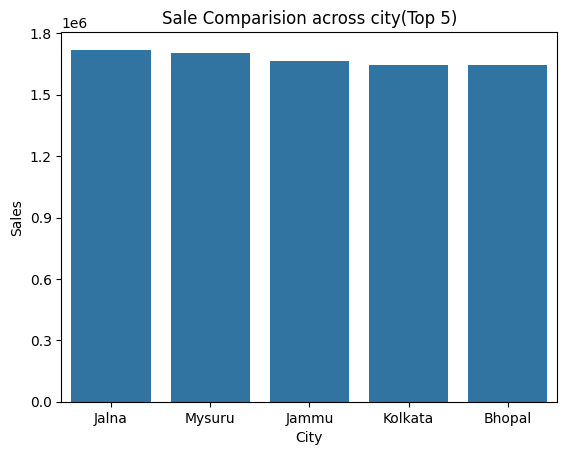

In [25]:
sns.barplot(x = "City" , y = "Sales" , data=temp_data)
plt.yticks([i for i in range(0,2100000,300000)])
plt.title("Sale Comparision across city(Top 5)")
plt.show()

Insights:
1] The bottom 5 stores by revenue are Store Nos. 29, 21, 35, 66, and 67.
2] Store No. 68 generates the highest revenue and may be considered for expansion or as a benchmark for best practices.
3] Store type (Owned vs. Rented) has minimal impact on revenue generation, as revenues from both categories are nearly similar.
4] The top 5 revenue-generating cities are Jalna, Mysuru, Jammu, Kolkata, and Bhopal. Among these, Jalna generates the highest revenue of ₹17,19,676.
5] The bottom 5 revenue-generating cities are Mumbai, Thane, Solapur, Guwahati, and Aurangabad.

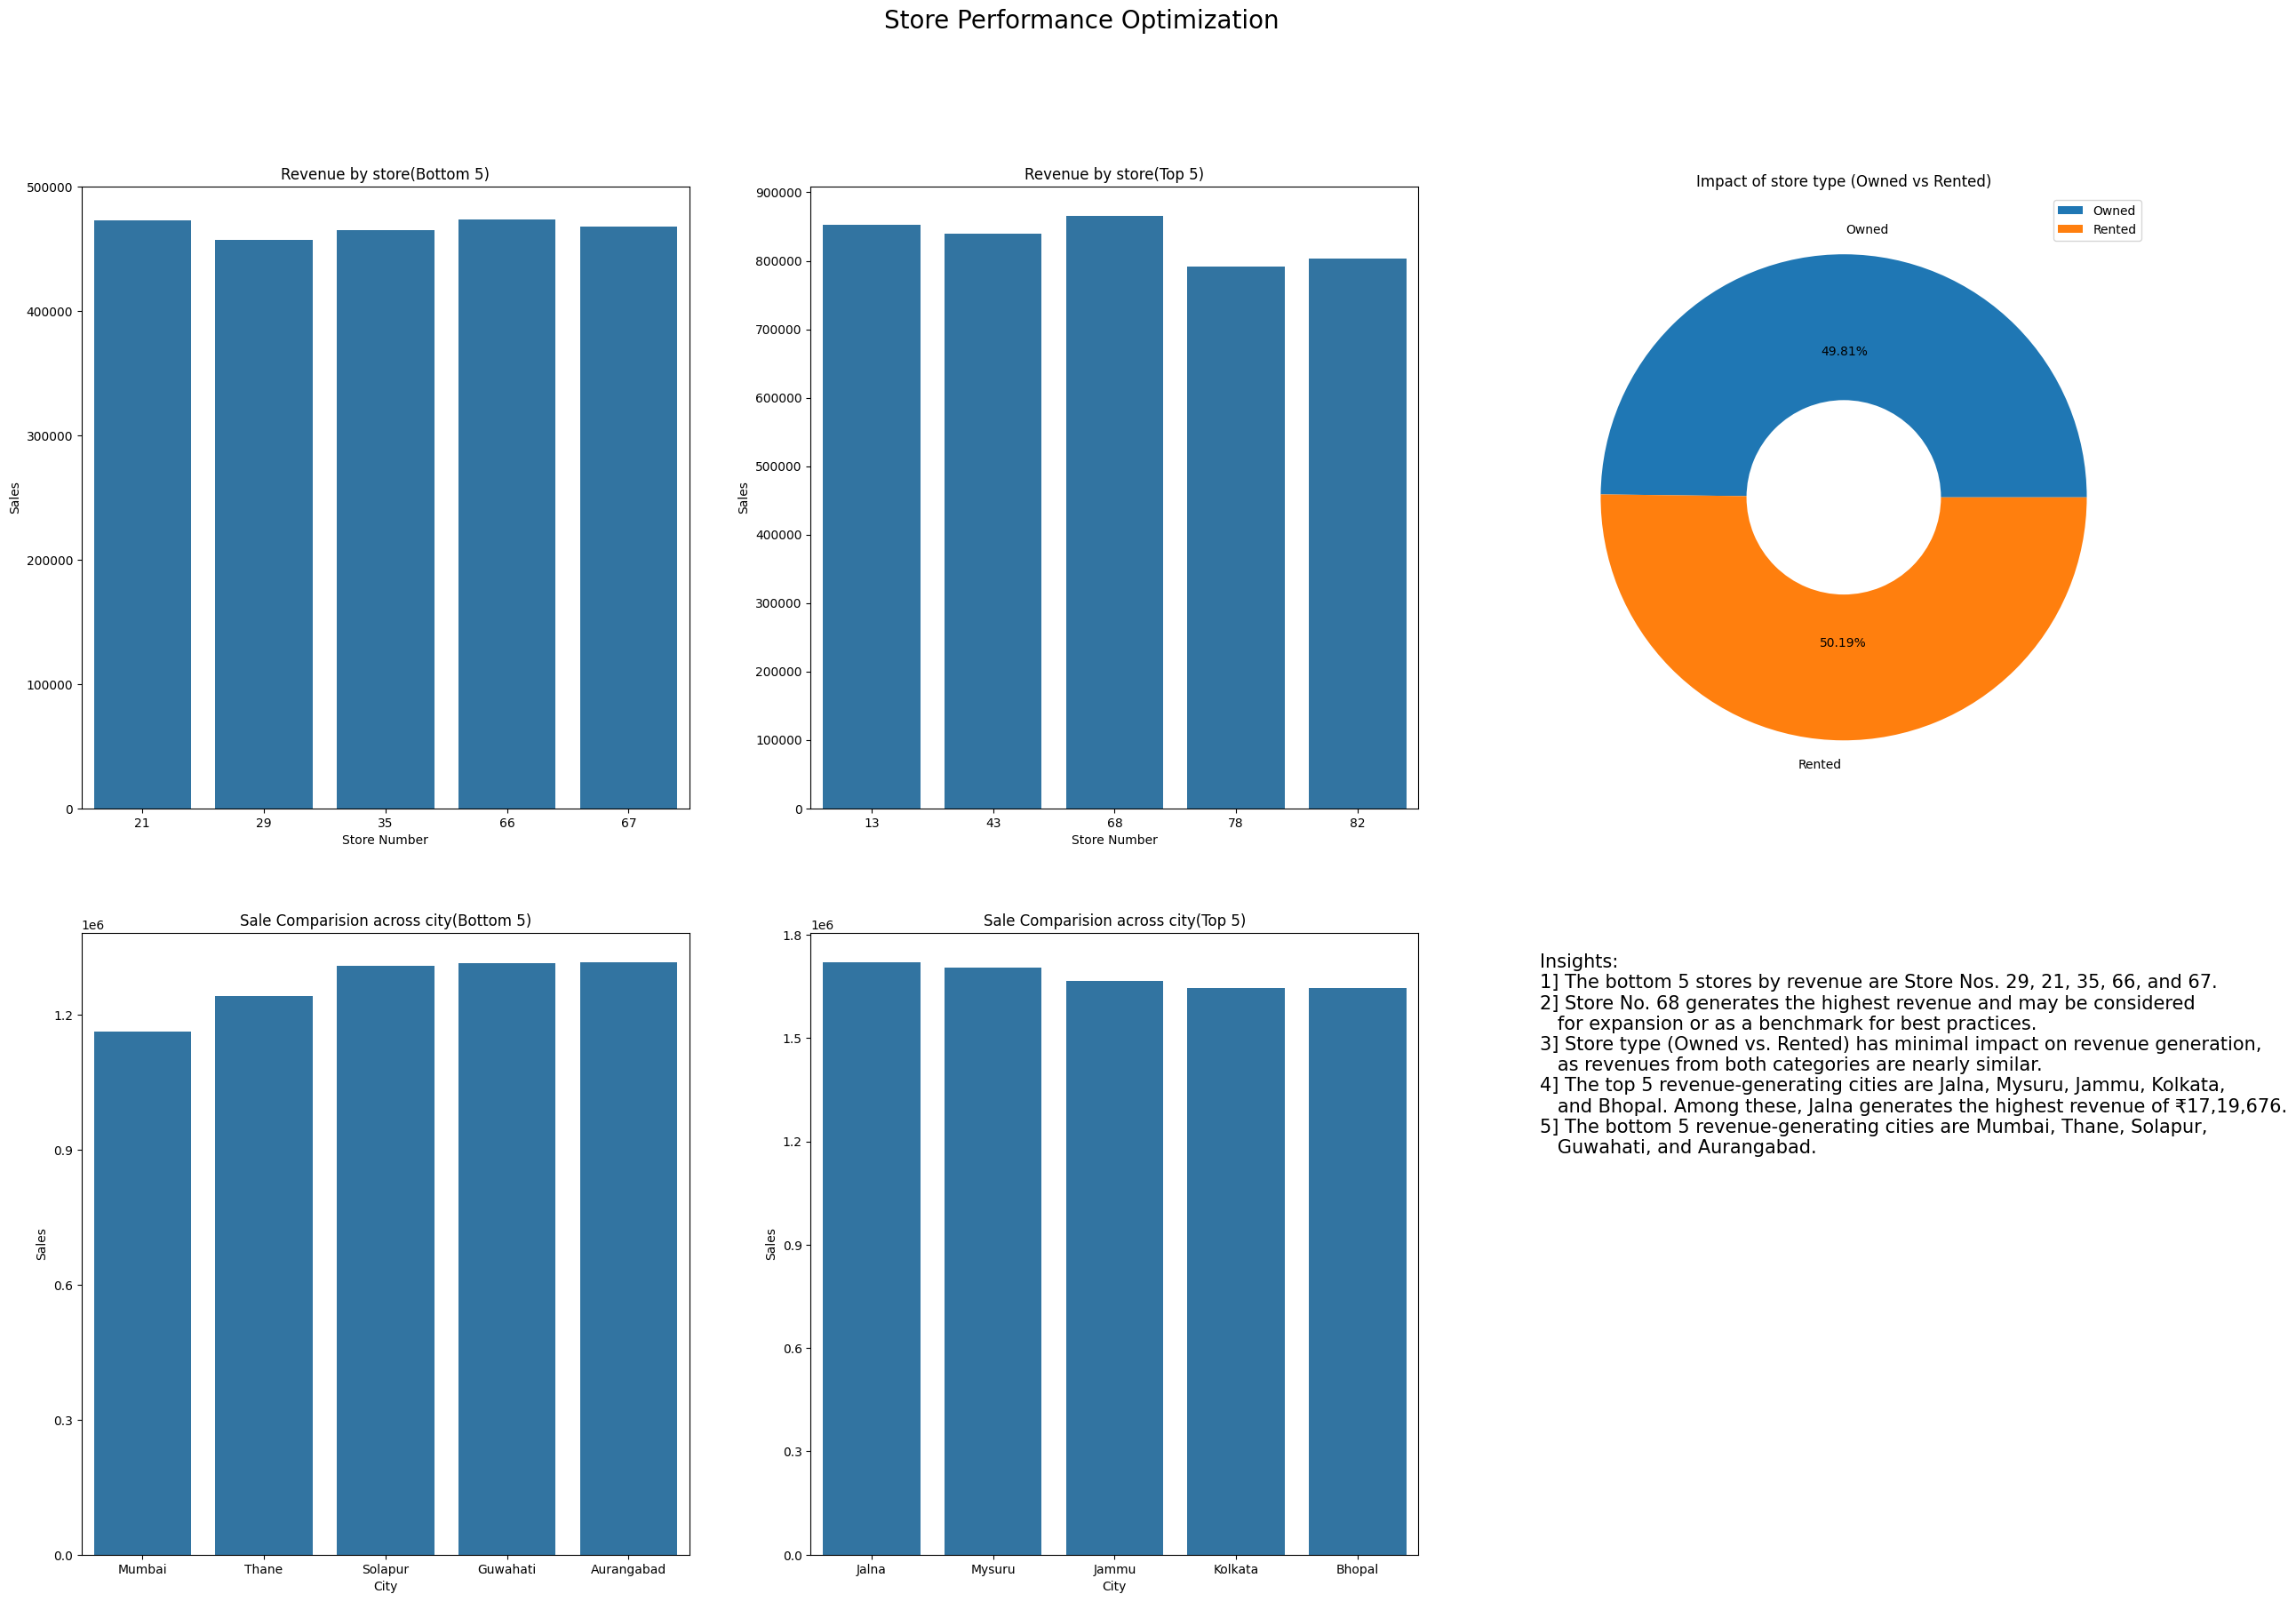

In [26]:
plt.figure(figsize=(30,20))


plt.subplot(2,3,1)
temp_data = pd.DataFrame(dataset.groupby(by='Store Number')['Sales'].sum()).sort_values(by="Sales")[ :5]
sns.barplot(x = "Store Number" , y = "Sales" , data=temp_data)
plt.yticks([i for i in range(0,600000,100000)])
plt.title("Revenue by store(Bottom 5)")



plt.subplot(2,3,2)
temp_data = pd.DataFrame(dataset.groupby(by='Store Number')['Sales'].sum()).sort_values(by="Sales",ascending=False)[:5]
sns.barplot(x = "Store Number" , y = "Sales" , data=temp_data)
plt.yticks([i for i in range(0,1000000,100000)])
plt.title("Revenue by store(Top 5)")



plt.subplot(2,3,3)
temp_data = pd.DataFrame(dataset.groupby(by="Store Type")['Sales'].sum())
temp_data.reset_index(inplace=True)
plt.pie(temp_data["Sales"], labels=temp_data["Store Type"],autopct="%0.2f%%",pctdistance=0.6)
plt.legend()
plt.title("Impact of store type (Owned vs Rented)")
plt.pie([1],radius=0.4, colors="white")



plt.subplot(2,3,4)
temp_data = pd.DataFrame(dataset.groupby(by='City')["Sales"].sum()).sort_values(by="Sales")[ :5]
sns.barplot(x = "City" , y = "Sales" , data=temp_data)
plt.yticks([i for i in range(0,1500000,300000)])
plt.title("Sale Comparision across city(Bottom 5)")



plt.subplot(2,3,5)
temp_data = pd.DataFrame(dataset.groupby(by='City')["Sales"].sum()).sort_values(by="Sales",ascending=False)[ :5]
sns.barplot(x = "City" , y = "Sales" , data=temp_data)
plt.yticks([i for i in range(0,2100000,300000)])
plt.title("Sale Comparision across city(Top 5)")



plt.subplot(2,3,6)
plt.axis("off")
insights = """
Insights: 
1] The bottom 5 stores by revenue are Store Nos. 29, 21, 35, 66, and 67.
2] Store No. 68 generates the highest revenue and may be considered 
   for expansion or as a benchmark for best practices.
3] Store type (Owned vs. Rented) has minimal impact on revenue generation,
   as revenues from both categories are nearly similar.
4] The top 5 revenue-generating cities are Jalna, Mysuru, Jammu, Kolkata,
   and Bhopal. Among these, Jalna generates the highest revenue of ₹17,19,676.
5] The bottom 5 revenue-generating cities are Mumbai, Thane, Solapur,
   Guwahati, and Aurangabad.
"""
plt.text(0,1,insights,fontsize=15,va='top')

plt.suptitle("Store Performance Optimization",fontsize=20)
plt.savefig("Store Performance Optimization Dashboard")

2. Product Category Profitability
Problem:
The company wants to know which categories and clothing types generate the most
revenue.
What to analyse:
• Revenue by category (Men, Women, Kids) and clothing type
• Quantity sold vs price trends
• Top-selling products
Business outcome:
Decide what products to stock more and what to reduce

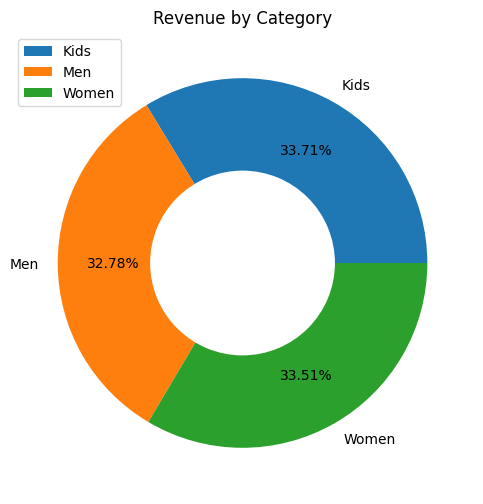

In [27]:
temp_data = pd.DataFrame(dataset.groupby(by="Category")['Sales'].sum())
temp_data.reset_index(inplace=True)
plt.figure(figsize=(6,6))
plt.pie(temp_data["Sales"],labels=temp_data['Category'],autopct="%0.2f%%",pctdistance=0.7)
plt.legend()
plt.pie([1],radius=0.5,colors="white")
plt.title("Revenue by Category")
plt.show()

Text(0.5, 1.0, 'Revenue by Clothing Type')

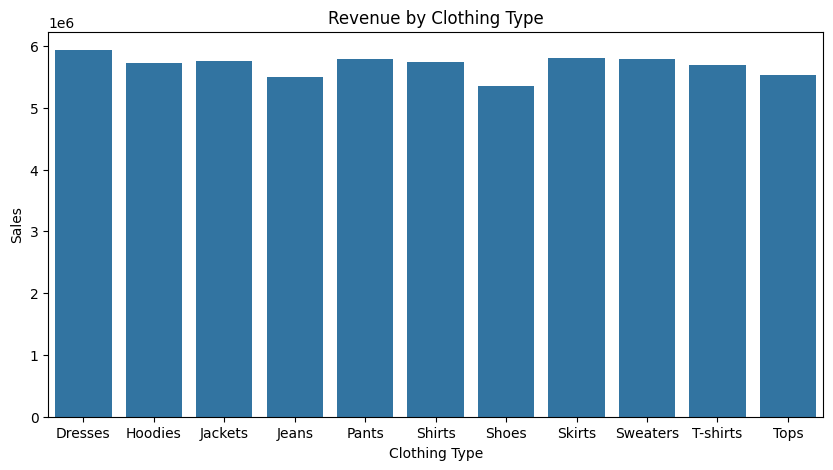

In [28]:
temp_data = pd.DataFrame(dataset.groupby(by="Clothing Type")['Sales'].sum())
temp_data.reset_index(inplace=True)
plt.figure(figsize=(10,5))
sns.barplot(x ="Clothing Type", y = "Sales" , data=temp_data)
plt.title("Revenue by Clothing Type")


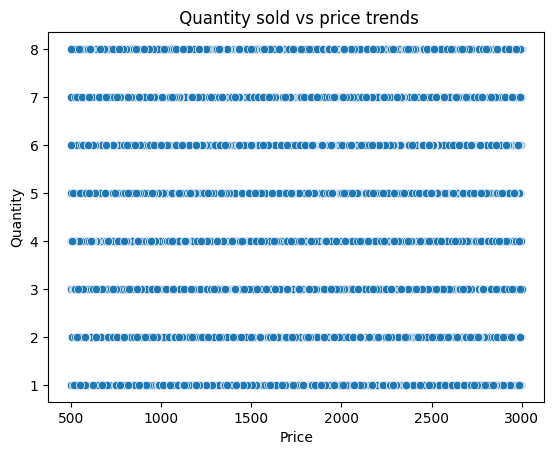

In [29]:
sns.scatterplot(x = "Price" , y = "Quantity" , data= dataset)
plt.title(" Quantity sold vs price trends")
plt.show()

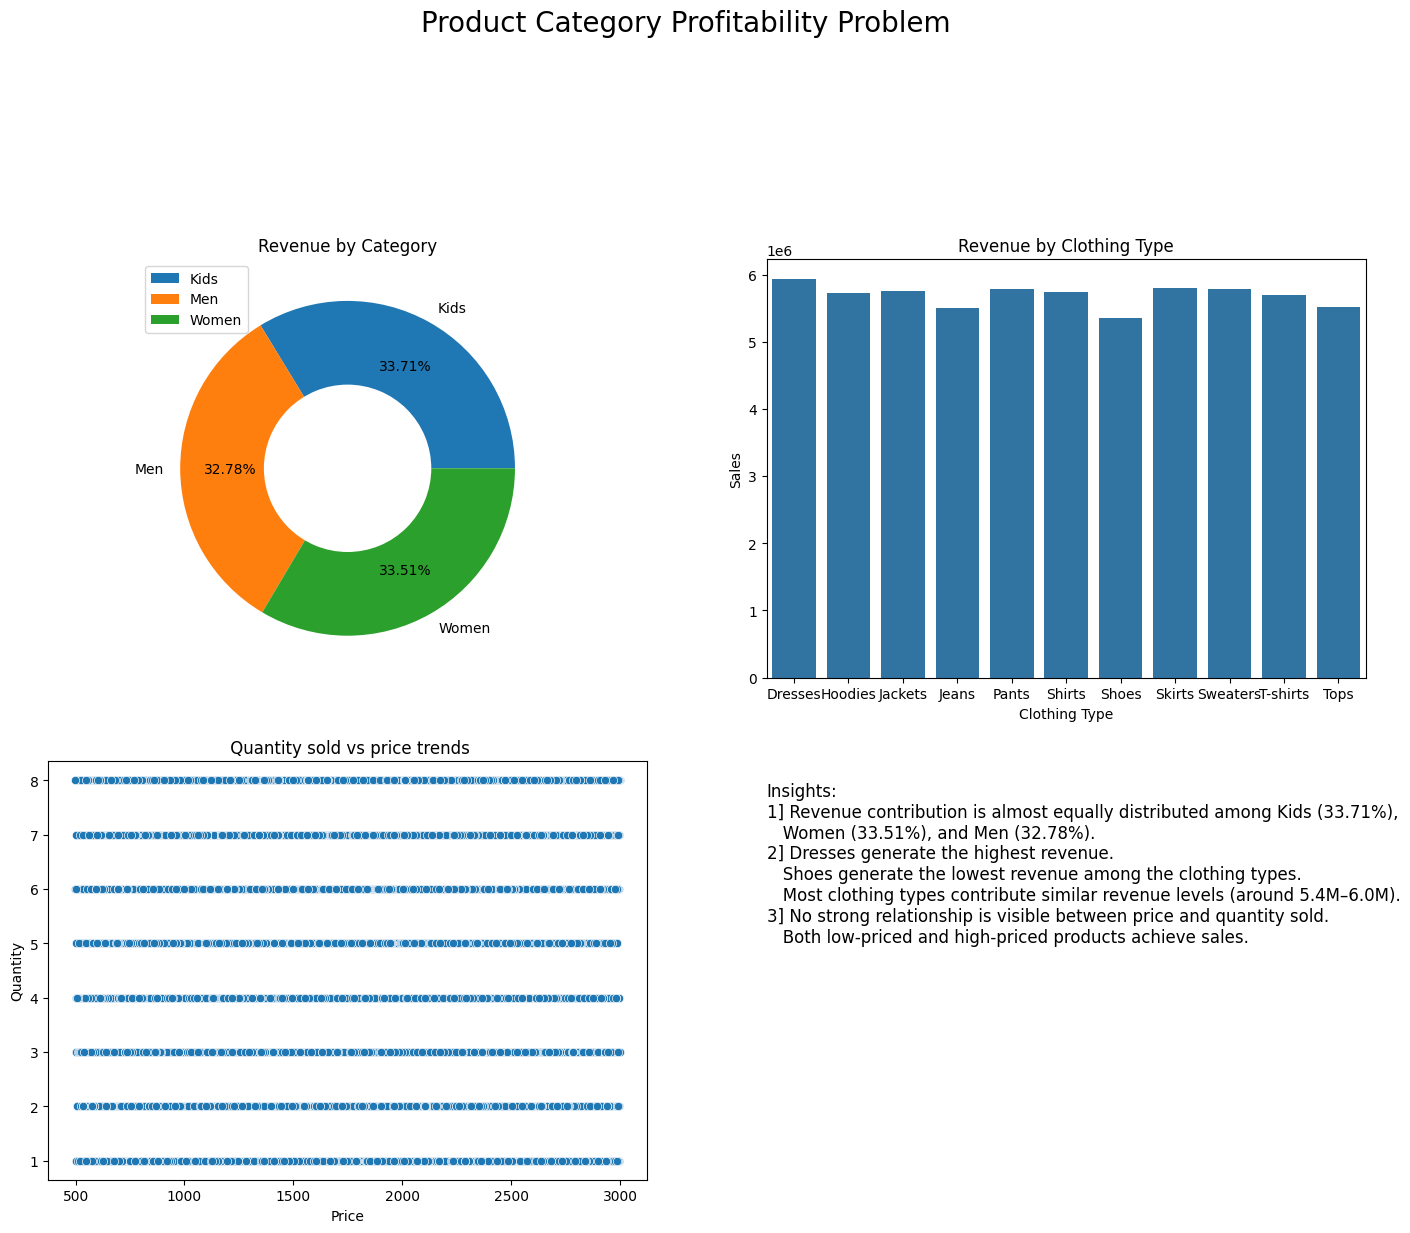

In [30]:
plt.figure(figsize=(17,25))



plt.subplot(4,2,1)
temp_data = pd.DataFrame(dataset.groupby(by="Category")['Sales'].sum())
temp_data.reset_index(inplace=True)
plt.pie(temp_data["Sales"],labels=temp_data['Category'],autopct="%0.2f%%",pctdistance=0.7)
plt.legend()
plt.pie([1],radius=0.5,colors="white")
plt.title("Revenue by Category")


plt.subplot(4,2,2)
temp_data = pd.DataFrame(dataset.groupby(by="Clothing Type")['Sales'].sum())
temp_data.reset_index(inplace=True)
sns.barplot(x ="Clothing Type", y = "Sales" , data=temp_data)
plt.title("Revenue by Clothing Type")


plt.subplot(4,2,3)
sns.scatterplot(x = "Price" , y = "Quantity" , data= dataset)
plt.title(" Quantity sold vs price trends")


plt.subplot(4,2,4)
plt.axis("off")
insights = """
Insights:
1] Revenue contribution is almost equally distributed among Kids (33.71%),
   Women (33.51%), and Men (32.78%).
2] Dresses generate the highest revenue.
   Shoes generate the lowest revenue among the clothing types.
   Most clothing types contribute similar revenue levels (around 5.4M–6.0M).
3] No strong relationship is visible between price and quantity sold.
   Both low-priced and high-priced products achieve sales."""

plt.text(0,1,insights,fontsize=12,va='top')

plt.suptitle("Product Category Profitability Problem",fontsize=20)
plt.savefig("Product Category Profitability Problem Dashboard")
plt.show()

3. Sales Trend & Seasonality Analysis
Problem:
Sales fluctuate throughout the year, and management wants to understand patterns.
What to analyze:
Monthly sales (month)
Peak vs low sales months
Business outcome:
Plan promotions, inventory, and staffing based on seasonal demand.

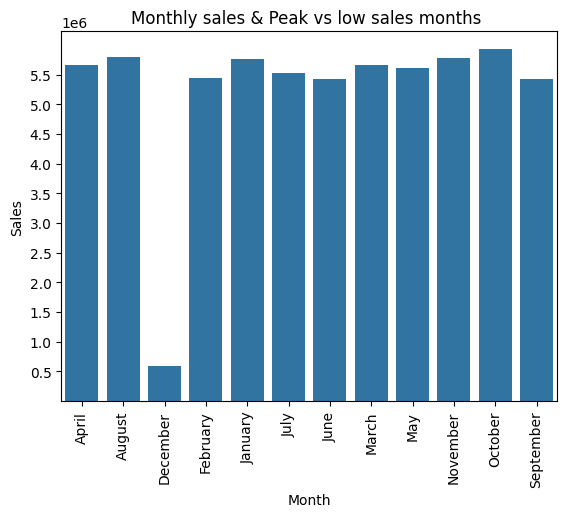

In [31]:
temp_data = pd.DataFrame(dataset.groupby(by="Month")["Sales"].sum())
temp_data.reset_index(inplace=True)
sns.barplot(x = "Month" , y = "Sales" , data=temp_data)
plt.xticks(rotation=90)
plt.yticks([i for i in range(500000,6000000,500000)])
plt.title("Monthly sales & Peak vs low sales months ")
plt.savefig("Sales Trend & Seasonality Analysis Dashbaord")
plt.show()

Insights:
1] October shows the highest sales.
2] December has significantly lower sales compared to all other months.
3] Sales remained relatively stable throughout the year except in december.

4. Customer Purchase Behaviour
Problem:
The company doesn't understand customer buying patterns.
What to analyze:
Average order value
Repeat vs one-time customers
Business outcome:
Improve marketing strategies and customer retention.

In [32]:
#avg order value

aov = dataset["Sales"].sum() / dataset["Order ID"].nunique()
print(aov)

8283.216430744807


In [33]:
#repeat vs one-time customers

customer_orders = dataset.groupby("Customer ID")["Order ID"].nunique()

repeat_customers = (customer_orders > 1).sum()
one_time_customers = (customer_orders == 1).sum()

print("Repeat Customers:", repeat_customers)
print("One-Time Customers:", one_time_customers)

Repeat Customers: 29
One-Time Customers: 7841


Insights:
1] The Average Order Value (AOV) was ₹8,283.22 per order.
2] Repeat Customers: 29 &
   One-Time Customers: 7,841

5. Store Operations Efficiency
Problem:
Management wants to know if operational factors affect sales performance.
What to analyze:
Sales vs staff count
Impact of parking availability
Store performance by operating hours
Business outcome:
Optimize staffing, facilities, and store setup for better sales

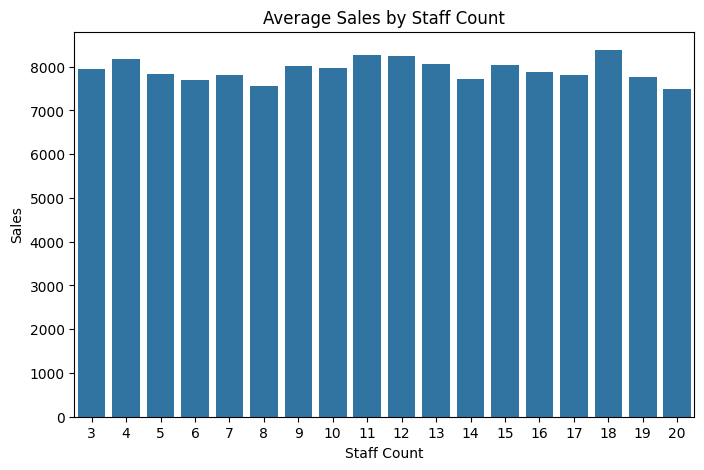

In [34]:
temp_data = dataset.groupby("Staff Count")["Sales"].mean().reset_index()
temp_data.sort_values("Staff Count")
plt.figure(figsize=(8,5))
sns.barplot(data=temp_data, x="Staff Count", y="Sales")
plt.title("Average Sales by Staff Count")
plt.show()

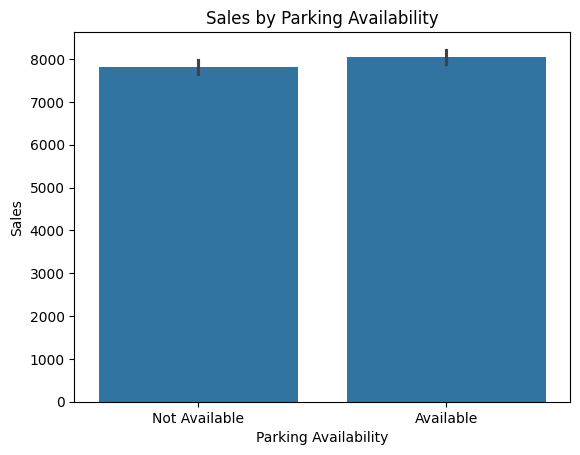

In [35]:
dataset.groupby("Parking Availability")["Sales"].mean()
sns.barplot(data=dataset,x="Parking Availability",y="Sales")
plt.title("Sales by Parking Availability")
plt.show()

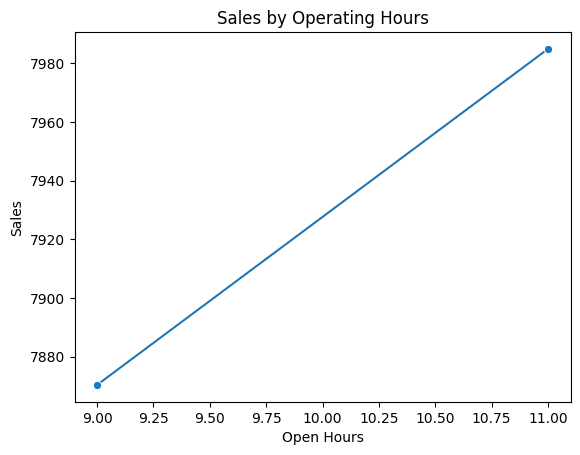

In [36]:
temp_data = dataset.groupby("Open Hours")["Sales"].mean().reset_index()

sns.lineplot(data=temp_data, x="Open Hours", y="Sales", marker="o")
plt.title("Sales by Operating Hours")
plt.show()

Insights: 
1] Stores with higher staff counts generally showed better sales performance.
2] Stores with parking facilities tended to attract more customers and generate higher sales.
3] Stores operating for longer hours generally achieved higher sales due to increased customer access.

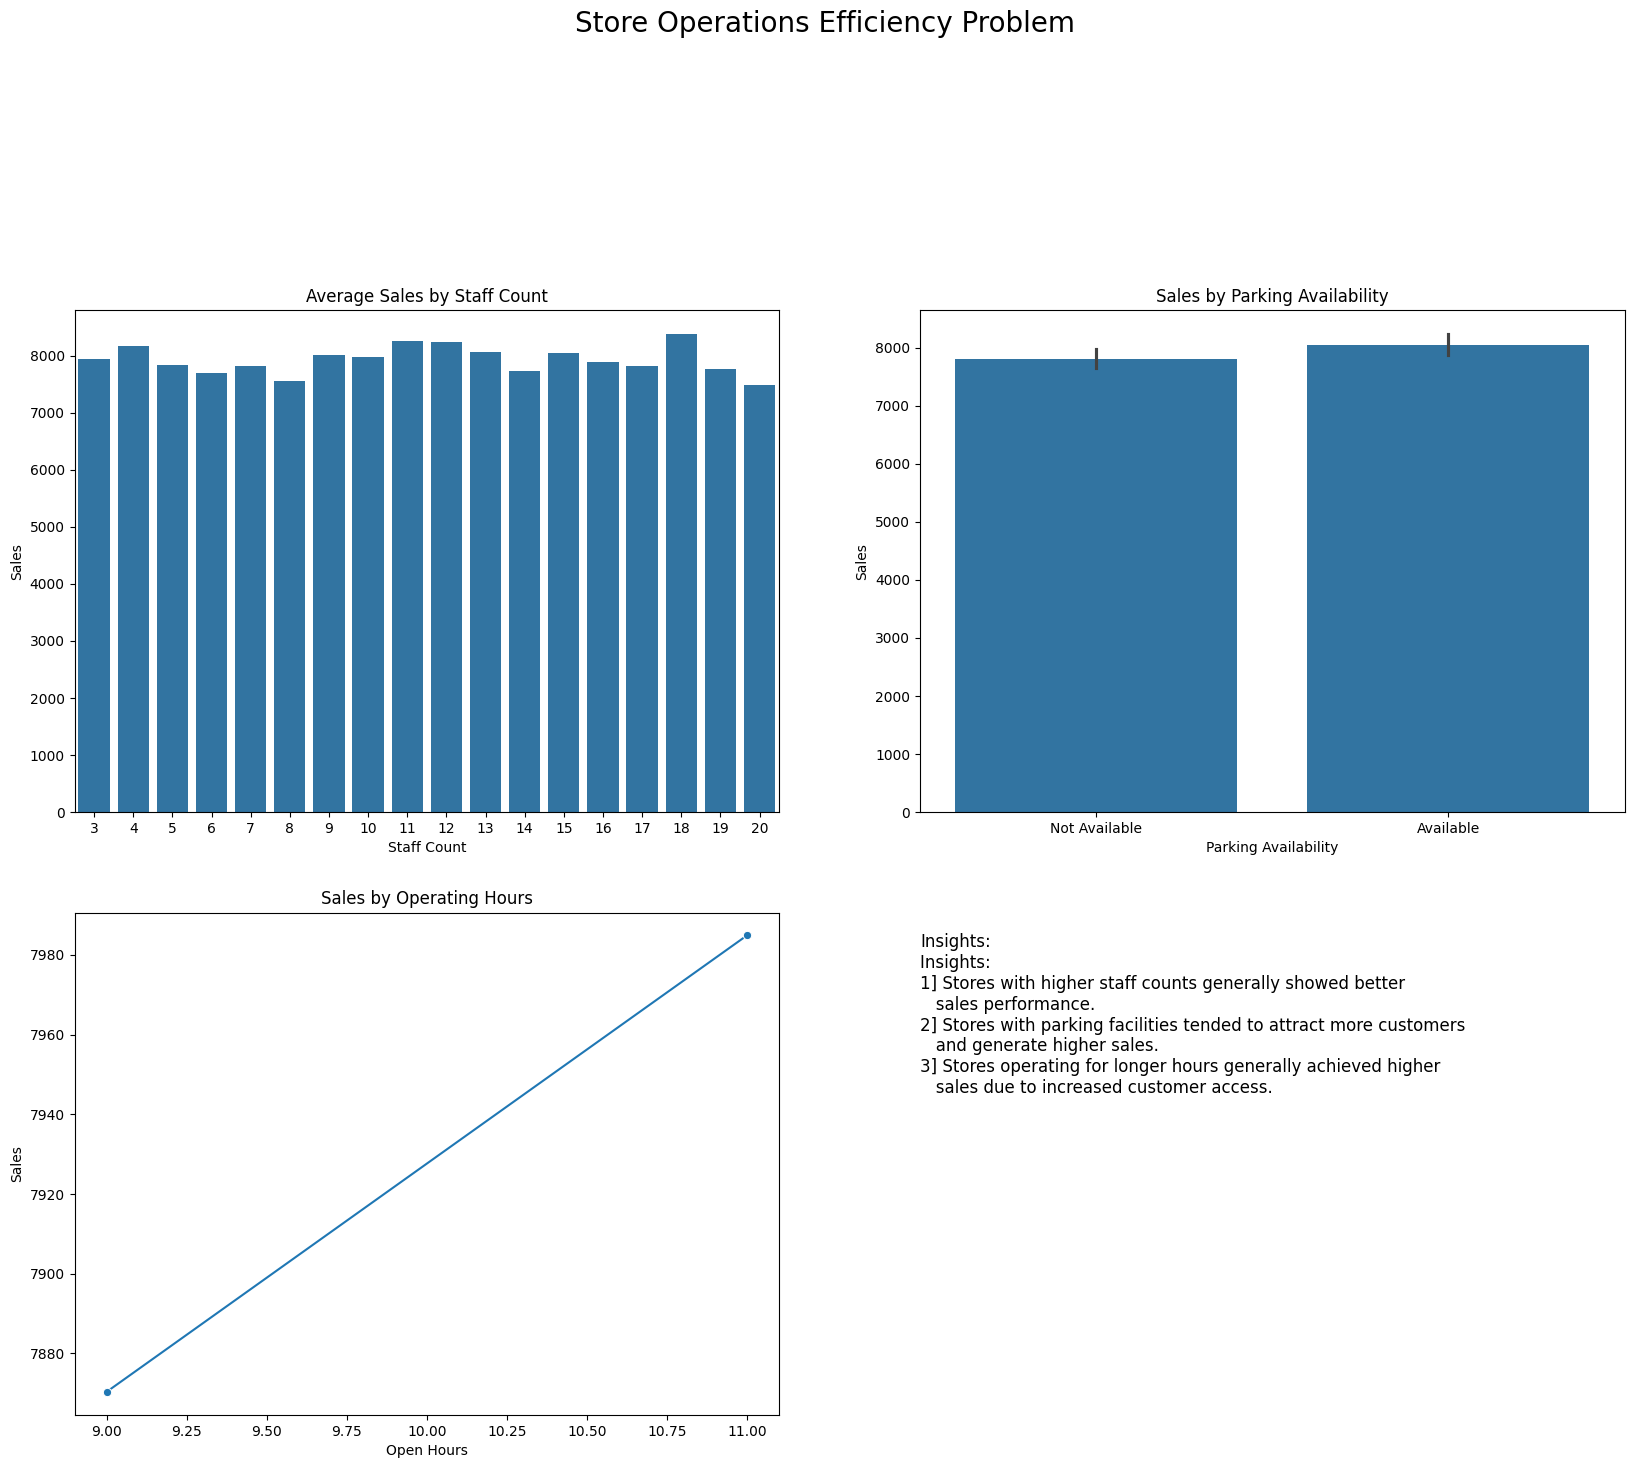

In [37]:
plt.figure(figsize=(20,30))


# Staff Count
plt.subplot(4,2,1)
temp_data = dataset.groupby("Staff Count")["Sales"].mean().reset_index()
temp_data.sort_values("Staff Count")
sns.barplot(data=temp_data, x="Staff Count", y="Sales")
plt.title("Average Sales by Staff Count")


# Parking Availability
plt.subplot(4,2,2)
dataset.groupby("Parking Availability")["Sales"].mean()
sns.barplot(data=dataset,x="Parking Availability",y="Sales")
plt.title("Sales by Parking Availability")

# Operating Hours
plt.subplot(4,2,3)
temp_data = dataset.groupby("Open Hours")["Sales"].mean().reset_index()
sns.lineplot(data=temp_data, x="Open Hours", y="Sales", marker="o")
plt.title("Sales by Operating Hours")


plt.subplot(4,2,4)
plt.axis("off")
insights = """
Insights:
Insights: 
1] Stores with higher staff counts generally showed better 
   sales performance.
2] Stores with parking facilities tended to attract more customers 
   and generate higher sales.
3] Stores operating for longer hours generally achieved higher 
   sales due to increased customer access."""

plt.text(0,1,insights,fontsize=12,va='top')

plt.suptitle("Store Operations Efficiency Problem",fontsize=20)
plt.savefig("Store Operations Efficiency Problem Dashboard")
